In [16]:
import gzip
import os
import pathlib
import tempfile
from concurrent.futures import ThreadPoolExecutor, as_completed
from io import StringIO, BytesIO

import earthaccess
import geopandas as gpd
import holoviews as hv
import hvplot.pandas
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shapely
import requests
import rioxarray as rxr
import xarray as xr
from tqdm.notebook import tqdm
import utilities as util
import glob
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import h5netcdf
import contextily as cx
import hvplot.xarray
import zipfile
import importlib
import download as dwld

importlib.reload(dwld)

data_dir = pathlib.Path().cwd().parent / 'data'
swot_path = data_dir / 'usgs_swot_data' / 'swot_timeseries_for_usgs_nodes.csv'
mrms_path_flag = data_dir / 'usgs_mrms_data' 
usgs_path = data_dir / 'usgs_stage_data'
start_time = '2023-01-01T00:00:00Z'
end_time = '2026-03-01T00:00:00Z'
precip_dir =  data_dir / 'pass_level_work'
os.makedirs(precip_dir, exist_ok=True)
precip_path = data_dir / 'pass_level_work/pass_119_MRMS_{var_name}.csv'


In [2]:
earthaccess.login()

In [3]:
pass_no = 119
# index=22
index=4 # This one sort of worked
river_results = earthaccess.search_data(short_name = 'SWOT_L2_HR_RIVERSP_D', 
                                        temporal = ('2024-02-01 00:00:00', '2025-07-15 23:59:59'), # can also specify by time
                                        granule_name = '*Node*_119_NA*')
earthaccess.download([river_results[index]], "./data_downloads")
print('data downloaded')
filename = earthaccess.results.DataGranule.data_links(river_results[index], access='external')
filename = filename[0].split("/")[-1]
filename
with zipfile.ZipFile(f'data_downloads/{filename}', 'r') as zip_ref:
    zip_ref.extractall('data_downloads')
filename_shp = filename.replace('.zip','.shp')
SWOT_HR_shp1 = gpd.read_file(f'data_downloads/{filename_shp}') 
SWOT_HR_shp1 = SWOT_HR_shp1[(SWOT_HR_shp1['lat']<45) & (SWOT_HR_shp1['lat']>25)]
#view the attribute table
SWOT_HR_shp1 

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

data downloaded


,reach_id,node_id,time,time_tai,time_str,lat,lon,lat_u,lon_u,river_name,...,p_wse,p_wse_var,p_width,p_wid_var,p_dist_out,p_length,p_dam_id,p_n_ch_max,p_n_ch_mod,geometry
23847,72552000103,72552000100223,7.670346e+08,7.670346e+08,2024-04-21T17:09:19Z,44.103097,-77.548889,0.000098,0.000098,Trent River,...,74.20,0.000000,2812.5,2751.889,786240.629,193.845007,0,1,1,POINT (-77.54162 44.09025)
23848,72552000103,72552000100233,7.670346e+08,7.670346e+08,2024-04-21T17:09:19Z,44.102520,-77.549711,0.000006,0.000032,Trent River,...,74.20,0.000000,2779.0,45.472,786425.890,185.261429,0,1,1,POINT (-77.54384 44.08969)
23849,72552000103,72552000100243,7.670346e+08,7.670346e+08,2024-04-21T17:09:19Z,44.100595,-77.551141,0.000003,0.000015,Trent River,...,74.20,0.000000,2834.0,1496.531,786645.175,219.285368,0,1,1,POINT (-77.54626 44.08918)
23850,72552000103,72552000100253,7.670346e+08,7.670346e+08,2024-04-21T17:09:19Z,44.096401,-77.552825,0.000002,0.000011,Trent River,...,74.20,0.000000,3005.0,842.139,786835.586,190.411099,0,1,1,POINT (-77.54867 44.08864)
23851,72552000103,72552000100263,7.670346e+08,7.670346e+08,2024-04-21T17:09:19Z,44.092008,-77.554164,0.000003,0.000016,Trent River,...,74.20,0.000000,2795.0,1558.250,787046.235,210.649011,0,1,1,POINT (-77.55088 44.0878)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52568,74269900881,74269900880501,7.670345e+08,7.670345e+08,2024-04-21T17:08:14Z,40.481093,-78.932540,0.000006,0.000030,Blacklick Creek,...,421.95,0.019284,42.0,37.837,3299022.136,239.335609,0,1,1,POINT (-78.93291 40.48011)
52569,74269900881,74269900880511,7.670345e+08,7.670345e+08,2024-04-21T17:08:14Z,40.481666,-78.931177,0.000004,0.000020,Blacklick Creek,...,422.10,0.000000,54.0,74.000,3299219.639,197.502898,0,1,1,POINT (-78.9306 40.48052)
52570,74269900881,74269900880521,7.670345e+08,7.670345e+08,2024-04-21T17:08:14Z,40.482380,-78.929489,0.000003,0.000016,Blacklick Creek,...,422.10,0.000000,42.0,5.760,3299411.737,192.097816,0,1,1,POINT (-78.92862 40.48148)
52571,74269900881,74269900880531,7.670345e+08,7.670345e+08,2024-04-21T17:08:14Z,40.483344,-78.927043,0.000003,0.000017,Blacklick Creek,...,422.10,0.000000,48.0,53.000,3299604.848,193.110943,0,1,1,POINT (-78.92665 40.48231)


In [49]:
for i, r in enumerate(river_results):
    print(i)
    print(r['umm']['GranuleUR'])
    print(r['umm']['TemporalExtent'])
    print(r['umm']['SpatialExtent'])
    print('-'*40)

0
SWOT_L2_HR_RiverSP_Node_011_119_NA_20240219T024405_20240219T025856_PGD0_01
{'RangeDateTime': {'EndingDateTime': '2024-02-19T02:58:56.587Z', 'BeginningDateTime': '2024-02-19T02:44:05.858Z'}}
{'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -86.45533277674173, 'SouthBoundingCoordinate': 10.100758088904952, 'EastBoundingCoordinate': -68.44589748709853, 'NorthBoundingCoordinate': 60.30762595987692}]}, 'Track': {'Cycle': 11, 'Passes': [{'Pass': 119, 'Tiles': ['164L', '165L', '166L', '167L', '168L', '169L', '170L', '171L', '172L', '173L', '174L', '175L', '176L', '177L', '178L', '179L', '180L', '181L', '182L', '183L', '184L', '185L', '186L', '187L', '188L', '189L', '190L', '191L', '192L', '193L', '194L', '195L', '196L', '197L', '198L', '199L', '200L', '201L', '202L', '203L', '204L', '205L', '206L', '207L', '208L', '209L', '210L', '211L', '212L', '213L', '214L', '215L', '216L', '217L', '218L', '219L', '220L', '221L', '222L', '223L', '224L', '225L', 

In [48]:
river_results

[Collection: {'Version': 'D', 'ShortName': 'SWOT_L2_HR_RiverSP_D'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -86.45533277674173, 'SouthBoundingCoordinate': 10.100758088904952, 'EastBoundingCoordinate': -68.44589748709853, 'NorthBoundingCoordinate': 60.30762595987692}]}, 'Track': {'Cycle': 11, 'Passes': [{'Pass': 119, 'Tiles': ['164L', '165L', '166L', '167L', '168L', '169L', '170L', '171L', '172L', '173L', '174L', '175L', '176L', '177L', '178L', '179L', '180L', '181L', '182L', '183L', '184L', '185L', '186L', '187L', '188L', '189L', '190L', '191L', '192L', '193L', '194L', '195L', '196L', '197L', '198L', '199L', '200L', '201L', '202L', '203L', '204L', '205L', '206L', '207L', '208L', '209L', '210L', '211L', '212L', '213L', '214L', '215L', '216L', '217L', '218L', '219L', '220L', '221L', '222L', '223L', '224L', '225L', '226L', '227L', '228L', '229L', '230L', '231L', '232L', '233L', '234L', '235L', '236L', '237L', '238L', '2

In [6]:
ts_df = SWOT_HR_shp1.copy().reset_index()
ts_df["time_utc"] = pd.to_datetime(ts_df["time_str"]).dt.tz_convert("UTC")
ts_df["mrms_time"] = ts_df["time_utc"].dt.floor("2min")
# for time in ts_df['mrms_time'].unique():
#     print(time)

time = ts_df['mrms_time'].unique()[1]
print(time)
test = fetch_raw_mrms(time, "PrecipRate_00.00",hourly=False)



2024-04-21 17:06:00+00:00


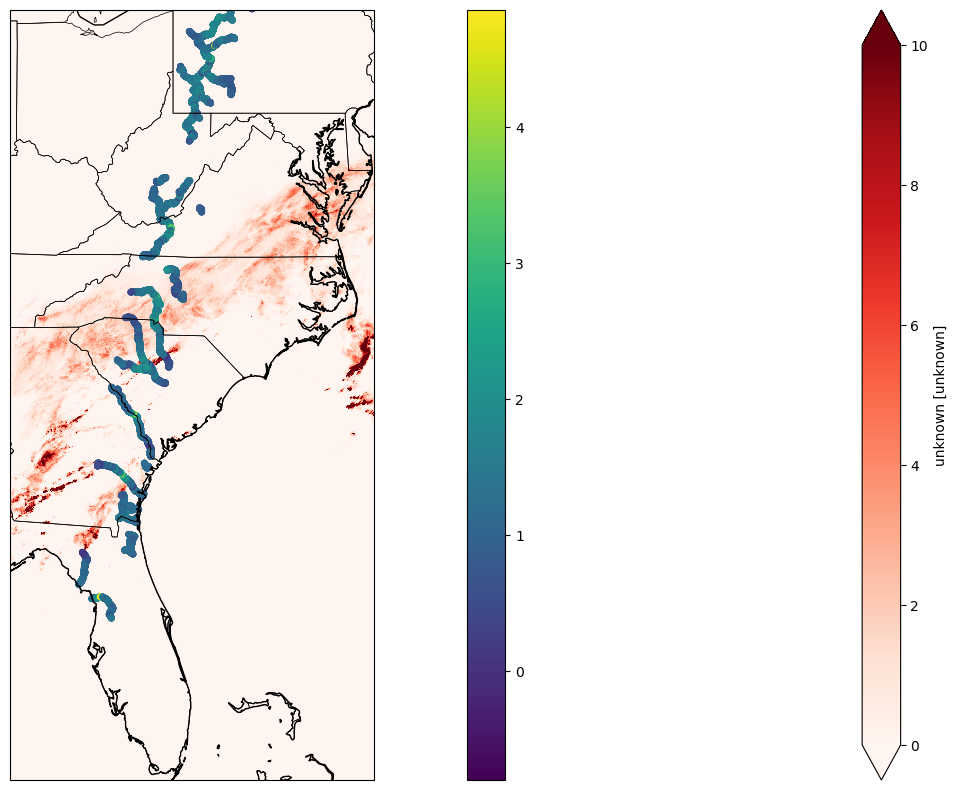

In [54]:

fig = plt.figure(figsize=(30, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot your DataArray
test.sel(longitude=slice(275,285)).plot(ax=ax, transform=ccrs.PlateCarree(), vmin=0,vmax=10, cmap="Reds")

# Add map features
ax.add_feature(cfeature.BORDERS, linewidth=1)
ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE)

SWOT_HR_shp1['rdr_sig0_log'] = np.log10(SWOT_HR_shp1['rdr_sig0'])
SWOT_HR_shp1.to_crs(epsg=4326).plot(
    ax=ax,
    column='rdr_sig0_log',          # color by this column
    cmap='viridis', 
    markersize=15,
    transform=ccrs.PlateCarree(),
    legend=True
)

# Optional: zoom to CONUS
# ax.set_extent([-83, -77, 33, 36], crs=ccrs.PlateCarree())
ax.set_extent([-85, -75, 25, 42], crs=ccrs.PlateCarree())
ax.set_title("")
plt.show()

In [18]:
# Preferences
importlib.reload(dwld)
use_cache = True
mrms_vars = dict(
    # flag=('PrecipFlag_00.00', False),  # Binary flag (0/1) for precipitation
    rate=('PrecipRate_00.00', False),  # Precipitation rate (mm/hr)
    quality=('RadarAccumulationQualityIndex_01H_00.00', True),
    quality_index=('RadarQualityIndex_00.00', False)  # Quality index (0-100)
    #zdr=('MergedZdr_00.00', False)  # Differential reflectivity (dB)
)
# Download MRMS data for each variable if not already downloaded
for _, (var_name, hourly) in mrms_vars.items():
    var_path = precip_path.parent / precip_path.name.format(var_name=var_name)
    print(var_path)
    if not var_path.exists() or not use_cache:
        dwld.download_mrms_parallel(
            SWOT_HR_shp1, 
            # test_df,
            var_name=var_name, 
            precip_path=precip_path,
            hourly=hourly)

c:\Users\matth\repos\swot-precip-validation\data\pass_level_work\pass_119_MRMS_PrecipRate_00.00.csv
c:\Users\matth\repos\swot-precip-validation\data\pass_level_work\pass_119_MRMS_RadarAccumulationQualityIndex_01H_00.00.csv


  0%|          | 0/1 [00:02<?, ?it/s]

c:\Users\matth\repos\swot-precip-validation\data\pass_level_work\pass_119_MRMS_RadarQualityIndex_00.00.csv


  0%|          | 0/3 [00:00<?, ?it/s]

In [39]:
rate_var = 'PrecipRate_00.00'
var_path = precip_path.parent / precip_path.name.format(var_name=rate_var)
precip_rate = pd.read_csv(var_path)

In [37]:
test_merge = SWOT_HR_shp1.copy()
test_merge['node_id'] = test_merge['node_id'].astype(int)

In [40]:
test_merge = pd.merge(test_merge, precip_rate, on="node_id")

In [42]:
test_merge

,reach_id,node_id,time,time_tai,time_str,lat,lon,lat_u,lon_u,river_name,...,p_wid_var,p_dist_out,p_length,p_dam_id,p_n_ch_max,p_n_ch_mod,geometry,rdr_sig0_log,mrms_time,PrecipRate_00.00
0,72552000103,72552000100223,7.670346e+08,7.670346e+08,2024-04-21T17:09:19Z,44.103097,-77.548889,0.000098,0.000098,Trent River,...,2751.889,786240.629,193.845007,0,1,1,POINT (-77.54162 44.09025),0.654754,2024-04-21 17:08:00+00:00,0.0
1,72552000103,72552000100233,7.670346e+08,7.670346e+08,2024-04-21T17:09:19Z,44.102520,-77.549711,0.000006,0.000032,Trent River,...,45.472,786425.890,185.261429,0,1,1,POINT (-77.54384 44.08969),0.898012,2024-04-21 17:08:00+00:00,0.0
2,72552000103,72552000100243,7.670346e+08,7.670346e+08,2024-04-21T17:09:19Z,44.100595,-77.551141,0.000003,0.000015,Trent River,...,1496.531,786645.175,219.285368,0,1,1,POINT (-77.54626 44.08918),0.922258,2024-04-21 17:08:00+00:00,0.0
3,72552000103,72552000100253,7.670346e+08,7.670346e+08,2024-04-21T17:09:19Z,44.096401,-77.552825,0.000002,0.000011,Trent River,...,842.139,786835.586,190.411099,0,1,1,POINT (-77.54867 44.08864),0.958373,2024-04-21 17:08:00+00:00,0.0
4,72552000103,72552000100263,7.670346e+08,7.670346e+08,2024-04-21T17:09:19Z,44.092008,-77.554164,0.000003,0.000016,Trent River,...,1558.250,787046.235,210.649011,0,1,1,POINT (-77.55088 44.0878),0.924951,2024-04-21 17:08:00+00:00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22086,74269900881,74269900880501,7.670345e+08,7.670345e+08,2024-04-21T17:08:14Z,40.481093,-78.932540,0.000006,0.000030,Blacklick Creek,...,37.837,3299022.136,239.335609,0,1,1,POINT (-78.93291 40.48011),0.924796,2024-04-21 17:08:00+00:00,0.0
22087,74269900881,74269900880511,7.670345e+08,7.670345e+08,2024-04-21T17:08:14Z,40.481666,-78.931177,0.000004,0.000020,Blacklick Creek,...,74.000,3299219.639,197.502898,0,1,1,POINT (-78.9306 40.48052),0.684217,2024-04-21 17:08:00+00:00,0.0
22088,74269900881,74269900880521,7.670345e+08,7.670345e+08,2024-04-21T17:08:14Z,40.482380,-78.929489,0.000003,0.000016,Blacklick Creek,...,5.760,3299411.737,192.097816,0,1,1,POINT (-78.92862 40.48148),0.886209,2024-04-21 17:08:00+00:00,0.0
22089,74269900881,74269900880531,7.670345e+08,7.670345e+08,2024-04-21T17:08:14Z,40.483344,-78.927043,0.000003,0.000017,Blacklick Creek,...,53.000,3299604.848,193.110943,0,1,1,POINT (-78.92665 40.48231),0.973405,2024-04-21 17:08:00+00:00,0.0


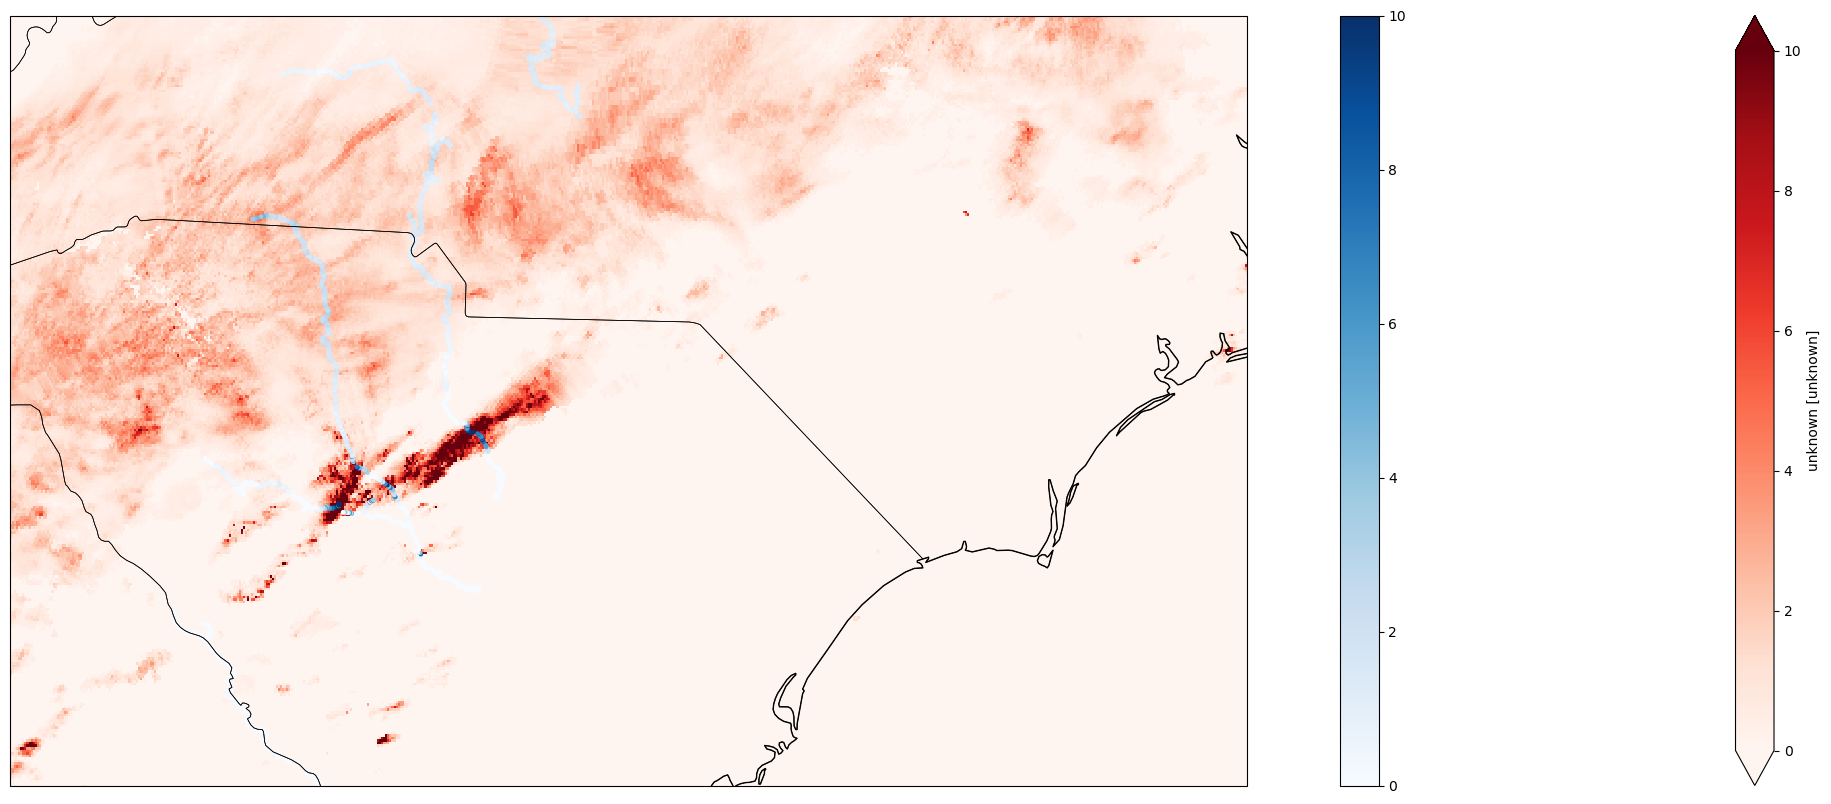

In [47]:

fig = plt.figure(figsize=(30, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot your DataArray
test.sel(longitude=slice(275,285)).plot(ax=ax, transform=ccrs.PlateCarree(), vmin=0,vmax=10, cmap="Reds")

# Add map features
ax.add_feature(cfeature.BORDERS, linewidth=1)
ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE)

SWOT_HR_shp1['rdr_sig0_log'] = np.log10(SWOT_HR_shp1['rdr_sig0'])
test_merge.to_crs(epsg=4326).plot(
    ax=ax,
    column='PrecipRate_00.00',          # color by this column
    cmap='Blues', 
    markersize=5,
    transform=ccrs.PlateCarree(),
    legend=True,
    vmin=0,
    vmax=10
)

# Optional: zoom to CONUS
ax.set_extent([-83, -77, 33, 36], crs=ccrs.PlateCarree())
# ax.set_extent([-85, -75, 25, 45], crs=ccrs.PlateCarree())
ax.set_title("")
plt.show()

In [5]:
import time
def fetch_raw_mrms(dt, var_name, hourly):
    ## Build MRMS URL
    # Convert to UTC just in case
    dt_utm0 = dt.tz_convert('UTC')
    # Get date components
    year, month, day = dt_utm0.year, dt_utm0.month, dt_utm0.day
    hour, minute = dt_utm0.hour, dt_utm0.minute
    # Round down to nearest even minute (MRMS data is every 2 minutes)
    if hourly:
        mrms_minute = 0  # Use the hour only
    else:
        # Round down to nearest even minute
        mrms_minute = (minute // 2) * 2
    # Format MRMS URL
    mrms_url = (
        "https://noaa-mrms-pds.s3.amazonaws.com/CONUS"
        f"/{var_name}"
        f"/{year}{month:02d}{day:02d}"
        f"/MRMS_{var_name}"
        f"_{year}{month:02d}{day:02d}-{hour:02d}{mrms_minute:02d}00"
        ".grib2.gz"
    )
    # print(mrms_url)
    # Download the MRMS data
    start_time = time.time()
    try:
        response = requests.get(mrms_url)
        if response.status_code != 200:
            print(f"Failed to download MRMS data for {dt_utm0}: "
                f"{response.status_code}")
            return pd.DataFrame(columns=['node_id', 'mrms_time', var_name])

        # Read the GRIB2 data from the gzipped content
        with gzip.open(BytesIO(response.content), 'rb') as gz:
            grib_bytes = gz.read()

        # Write to a temporary .grib2 file
        with tempfile.NamedTemporaryFile(suffix=".grib2", delete=False) as tmp:
            tmp.write(grib_bytes)
            tmp_path = tmp.name

        # Read it with xarray + cfgrib
        ds = xr.open_dataset(tmp.name, engine='cfgrib')
        
        end_time = time.time()
        # print(f"Downloaded test MRMS data for {dt_utm0} in {end_time - start_time:.2f} seconds")
        ds_var_name = list(ds.data_vars)[0]

        return ds[ds_var_name]
    except Exception as e:
        print(f"Error processing MRMS data for {dt_utm0}: {e}")
        return pd.DataFrame(columns=['node_id', 'mrms_time', var_name])